In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('dark_background')

from IPython.display import clear_output

from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer

from sklearn.metrics import accuracy_score, roc_auc_score

from tqdm.auto import trange, tqdm


import random
import numpy as np
import os
import math
import time

from dataclasses import dataclass

SEED = 42
BATCH_SIZE = 64
device = torch.device("mps") if torch.mps.is_available() else torch.device("cpu")

# Необходимые классы

In [34]:
class BaseQuantizer(nn.Module):
    def forward(self, x):
        raise NotImplementedError

class IdentityQuantizer(BaseQuantizer):
    def forward(self, x):
        return x

def round_good(x):
    return (x.round() - x).detach() + x # Чтобы текли градиенты

def grad_scaler(x, scale):
    return (x - x * scale).detach() + x * scale

def inverse_softplus(x, eps: float = 1e-8):
    x_tensor = torch.tensor(x)
    x_tensor = torch.clamp(x_tensor - eps, min=eps)
    return torch.log(torch.expm1(x_tensor))

class LSQQuantizer(BaseQuantizer):
    def __init__(self, bits: int = 8, eps: float = 1e-8):
        super().__init__()

        self.bits = bits
        raw_scale_init = inverse_softplus(1.0, eps)
        self.raw_scale = nn.Parameter(raw_scale_init)
        self.initialized = False
        self.eps = eps

        self.qmin = -(2 ** (bits - 1)) + 1 # для симметрии можно +1
        self.qmax = (2 ** (bits - 1)) - 1

    def get_scale(self):
        return F.softplus(self.raw_scale)
        
    # Подбирает нормальный scale для начала по данным
    def init_scale(self, x):
        with torch.no_grad():
            mean_abs = x.detach().abs().mean()
            if mean_abs <= self.eps:
                return False
                
            init_value = 2 * mean_abs / math.sqrt(self.qmax)
            init_value = init_value.clamp_min(self.eps)
            raw_init = inverse_softplus(init_value, self.eps).to(
                device=self.raw_scale.device,
                dtype=self.raw_scale.dtype
            )

            self.raw_scale.copy_(raw_init) #.reshape_as(self.raw_scale))
        self.initialized = True

        return True

    def forward(self, x):
        if not self.initialized:
            was_initialized = self.init_scale(x)

            if not was_initialized:
                return x

        grad_factor = 1.0 / math.sqrt(x.numel() * self.qmax)

        scale = self.get_scale()
        scale = grad_scaler(scale, grad_factor)

        
        x_scaled = x / scale
        x_clamped = torch.clamp(x_scaled, self.qmin, self.qmax)
        x_rounded = round_good(x_clamped)
        x_fake_quantized = x_rounded * scale

        return x_fake_quantized

class PACTQuantizer(BaseQuantizer):
    def __init__(self, bits: int = 8, alpha_init: float = 10.0, eps: float = 1e-8):
        super().__init__()

        self.bits = bits
        self.eps = eps
        self.raw_alpha = nn.Parameter(inverse_softplus(alpha_init))

        self.register_buffer("qmin", torch.tensor(0.0))
        self.qmax = (2 ** bits) - 1

    def get_alpha(self):
        return F.softplus(self.raw_alpha)

    def forward(self, x):
        alpha = self.get_alpha()

        x_clipped = torch.clamp(x, self.qmin, alpha)
        scale = alpha / self.qmax

        x_scaled = x_clipped / scale
        x_rounded = round_good(x_scaled)
        
        x_fake_quantized = x_rounded * scale

        return x_fake_quantized

class TQTQuantizer(BaseQuantizer):
    def __init__(self, bits: int = 8, alpha_init: float = 10.0, eps: float = 1e-8):
        super().__init__()

        self.bits = bits
        self.eps = eps
        self.raw_alpha = nn.Parameter(inverse_softplus(alpha_init))

        self.qmin = -(2 ** (bits - 1)) + 1
        self.qmax = 2 ** (bits - 1) - 1

    def get_alpha(self):
        return F.softplus(self.raw_alpha)

    def forward(self, x):
        alpha = self.get_alpha()
        
        scale = alpha / self.qmax
        #scale = scale.clamp_min(self.eps)
        
        x_clipped = torch.clamp(x, -alpha, alpha)
        x_scaled = x_clipped / scale
        x_rounded = round_good(x_scaled)
        x_clamped = torch.clamp(x_rounded, self.qmin, self.qmax)
        x_fake_quantized = x_clamped * scale

        return x_fake_quantized

class ADAQuantizer(BaseQuantizer):
    def __init__(
            self,
            weights: torch.tensor,
            bits: int = 8,
            eps: float = 1e-8,
            val: bool = False
        
    ):
        super().__init__()
    
        self.bits = bits
        self.eps = eps

        self.qmin = -(2 ** (bits - 1)) + 1
        self.qmax = 2 ** (bits - 1) - 1

        self.val = val # Это для жесткого округдения во врмея инференса

        with torch.no_grad():
            max_abs = weights.detach().abs().max()
            scale = max_abs / self.qmax
            scale = scale.clamp_min(self.eps)

            self.register_buffer("scale", scale)
            
            w_scaled = weights / scale
            w_floor = torch.floor(w_scaled)
            w_fraction = w_scaled - w_floor

            w_fraction = w_fraction.clamp(1e-6, 1 - 1e-6)
            alpha_init = torch.log(w_fraction / (1 - w_fraction)) # Считаем логиты для сигмоиды
        
        self.alpha = nn.Parameter(alpha_init) # Выдает примерно те же значения для дробных частей

    def regularization(self): # Не забыть добавить к лоссу при обучении
        h = torch.sigmoid(self.alpha)
        return torch.mean(1.0 - torch.abs(2.0 * h - 1.0))
        
    def forward(self, weights):
        w_scaled = weights / self.scale 

        if not self.val:
            w_round = torch.sigmoid(self.alpha)
        else:
            w_round = (torch.sigmoid(self.alpha) >= 0.5).float()

        w_floor = torch.floor(w_scaled)
        w_int = w_floor + w_round
        w_int = w_int.clamp(self.qmin, self.qmax)

        w_fake_quantized = w_int * self.scale

        return w_fake_quantized

from itertools import combinations
def build_apot_levels(bits: int = 8, num_powers: int = 8, max_addends: int = 2):
    max_levels = 2 ** bits

    powers = [2 ** -i for i in range(num_powers)]
    positive_levels = {0.0}

    for addends_count in range(1, max_addends + 1):
        for combo in combinations(powers, addends_count):
            value = sum(combo)
            if value <= 1.0:
                positive_levels.add(value)
            
    signed_levels = set()
    for value in positive_levels:
        signed_levels.add(value)
        signed_levels.add(-value) # Вроде можно всегда представить как строгую сумму или строгую минус сумму других

    levels = torch.tensor(sorted(signed_levels))

    if levels.numel() > max_levels:
        raise ValueError("Bad arguments, too many values for so small bits")

    return levels

def nearest_apot_levels(x_norm: torch.tensor, levels: torch.tensor):
    x_flat = x_norm.reshape(-1)
    right_indices = torch.bucketize(x_flat, levels).clamp(0, len(levels) - 1)
    left_indices = (right_indices - 1).clamp(0, len(levels) - 1)

    left_values = levels[left_indices]
    right_values = levels[right_indices]

    left_dist = (x_flat - left_values).abs()
    right_dist = (right_values - x_flat).abs()

    nearest = torch.where(right_dist < left_dist, right_values, left_values)

    return nearest.view_as(x_norm)
        
    
class APoTQuantizer(BaseQuantizer):
    def __init__(
        self,
        bits: int = 8,
        eps: float = 1e-8,
        max_addends: int = 3, #сколько степеней двоек складываем
        num_powers: int = 8,
        alpha_init: float = 1.0,
    ):
        super().__init__()
        
        self.bits = bits
        self.eps = eps
        self.max_addends = max_addends

        levels = build_apot_levels(
            bits, num_powers, self.max_addends
        )
        self.register_buffer("levels", levels)

        raw_alpha_init = inverse_softplus(alpha_init)
        self.raw_alpha = nn.Parameter(raw_alpha_init)

    def get_alpha(self):
        return F.softplus(self.raw_alpha)
        
    def forward(self, x):
        alpha = self.get_alpha()
        x_clipped = x.clamp(-alpha, alpha)
        x_norm = x_clipped / alpha
        x_nearest = nearest_apot_levels(x_norm, self.levels)
        x_rounded = x_norm + (x_nearest - x_norm).detach()

        return x_rounded * alpha
        

Универсальная фабрика квантайзеров

In [33]:
@dataclass
class QuantConfig:
    method: str = "fp32"
    bits: int = 8

    pact_alpha_init: float = 10.0

    apot_num_powers: int = 8
    apot_max_addends: int = 3
    apot_alphas_init: int = 1.0

    ada_val: bool = False
#    ada_weights: torch.tensor = torch.tensor(1)
    tqt_alpha_init: floar = 10.0


class FabricQuantizer:
    def __init__(self, config):
        self.config = config

    def make_activations(self, name: str = ""):
        method = self.config.method
        
        if method == "fp32":
            return IdentityQuantizer()
        if method == "lsq":
            return LSQQuantizer(
                bits=self.config.bits,
            )
        if method == "pact":
            return PACTQuantizer(
                bits=self.config.bits,
                alpha_init=self.config.pact_alpha_init,
            )
        if method == "apot":
            return APoTQuantizer(
                bits=self.config.bits,
                max_addends=self.config.apot_max_addends,
                num_powers=self.config.apot_num_powers,
                alpha_init=self.config.apot_alphas_init
            )
        if method == "ada":
            return IdentityQuantizer()

        if method == "tqt":
            return TQTQuantizer(
                bits=self.config.bits,
                alpha_init=self.config.pact_alpha_init
            )

    def make_weights(self, weight, name: str = ""):
        method = self.config.method
        
        if method == "fp32":
            return IdentityQuantizer()
        if method == "lsq":
            return LSQQuantizer(
                bits=self.config.bits,
            )
        if method == "pact":
            return IdentityQuantizer() # Потому что на активациях 
            
        if method == "apot":
            return APoTQuantizer(
                bits=self.config.bits,
                max_addends=self.config.apot_max_addends,
                num_powers=self.config.apot_num_powers,
                alpha_init=self.config.apot_alphas_init
            )
        if method == "ada":
            return ADAQuantizer(
                weight,
                bits=self.config.bits,
                val=self.config.ada_val
            )
        if method == "tqt":
            alpha_init = weight.detach().abs().max()
            alpha_init = max(alpha_init, 1e-8)
            return TQTQuantizer(
                bits=self.config.bits,
                alpha_init=alpha_init
            )

In [4]:
class LinearQuantized(nn.Module):
    def __init__(
        self,
        in_size,
        out_size,
        quant_factory,
        bias: bool = True
    ):
        super().__init__()

        self.weights = nn.Parameter(torch.empty(out_size, in_size))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_size))
        else:
            self.bias = None

        self.reset_parameters()

        self.weight_quantizer = quant_factory.make_weights(self.weights, "linear_weights")
        self.input_quantizer = quant_factory.make_activations("linear_input")

    def reset_parameters(self):
        nn.init.kaiming_uniform_(self.weights)

        if self.bias is not None:
            out_size = self.weights.shape[1]
            stdv = 1. / math.sqrt(out_size)
            nn.init.uniform_(self.bias, -stdv, stdv)

    def forward(self, x):
        x_q = self.input_quantizer(x)
        w_q = self.weight_quantizer(self.weights)

        result = F.linear(x_q, w_q, self.bias) # Надо добавить квантование биаса

        return result

class LSTMCellQuantized(nn.Module):
    def __init__(
        self,
        inp_size,
        hidden_size,
        quant_factory,
        quantized_cell_state: bool = False
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.quantized_cell_state = quantized_cell_state
        
        self.weights_inp = nn.Parameter(torch.empty(4 * hidden_size, inp_size))
        self.weights_hid = nn.Parameter(torch.empty(4 * hidden_size, hidden_size))
        
        self.bias_hid = nn.Parameter(torch.empty(4 * hidden_size))
        self.bias_inp = nn.Parameter(torch.empty(4 * hidden_size))

        self.reset_parameters()

        self.x_quantizer = quant_factory.make_activations("lstm_x")
        self.h_quantizer = quant_factory.make_activations("lstm_h")
        self.c_quantizer = quant_factory.make_activations("lstm_c")

        self.weights_inp_quantizer = quant_factory.make_weights(self.weights_inp, "lstm_weights_inp")
        self.weights_hid_quantizer = quant_factory.make_weights(self.weights_hid, "lstm_weights_hid")

    def reset_parameters(self):
        stdv = 1. / (math.sqrt(self.hidden_size))

        for layer in [self.weights_inp, self.weights_hid, self.bias_hid, self.bias_inp]:
            nn.init.uniform_(layer, -stdv, stdv)

    def forward(self, x, state):
        x_q = self.x_quantizer(x)
        h, c = state
        h_q = self.h_quantizer(h)
        
        if self.quantized_cell_state:
            c_q = self.c_quantizer(c)
        else:
            c_q = c

        weights_inp_q = self.weights_inp_quantizer(self.weights_inp)
        weights_hid_q = self.weights_hid_quantizer(self.weights_hid)

        gates = F.linear(x_q, weights_inp_q, self.bias_inp) + F.linear(h_q, weights_hid_q, self.bias_hid)

        i_gate, f_gate, c_gate, o_gate = gates.chunk(4, dim=1)

        i_gate = torch.sigmoid(i_gate)
        f_gate = torch.sigmoid(f_gate)
        c_gate = torch.tanh(c_gate)
        o_gate = torch.sigmoid(o_gate)

        c_new = f_gate * c_q + i_gate * c_gate
        h_new = o_gate * torch.tanh(c_new)

        return h_new, c_new

class LSTMQuantized(nn.Module):
    def __init__(
        self,
        inp_size,
        hidden_size, 
        quant_factory,
        quantized_cell_state: bool = False
    ):
        super().__init__()

        self.cell = LSTMCellQuantized(inp_size, hidden_size, quant_factory, quantized_cell_state)
        self.hidden_size = hidden_size

    def forward(self, x, state=None):
        batch_size, seq_len, _ = x.shape

        if state is None:  
            h = x.new_zeros(batch_size, self.hidden_size)
            c = x.new_zeros(batch_size, self.hidden_size)
        else:
            h, c = state
        
        outputs = []
        for t in range(seq_len):
            h, c = self.cell(x[:, t, :], (h, c))
            outputs.append(h.unsqueeze(1))
        outputs = torch.cat(outputs, dim=1)

        return outputs, (h, c)

class LSTMClassifierQuantized(nn.Module):
    def __init__(
        self, 
        emb_size,
        #inp_size,
        hidden_size, 
        quant_factory, 
        pad_idx,
        vocab_size=30522,
        quantized_cell_state=True
    ):
        super().__init__()
        
        self.emb = nn.Embedding(vocab_size, emb_size, pad_idx)
        self.lstm = LSTMQuantized(emb_size, hidden_size, quant_factory, quantized_cell_state)
        self.linear = LinearQuantized(hidden_size, 1, quant_factory)

    def forward(self, input_ids, attention_mask=None):
        input_ids = input_ids.long()
        emb = self.emb(input_ids)
        outputs, (h, c) = self.lstm(emb)

        if attention_mask is not None: # Потому что input_ids = [batch, max_seq_len, embeddings] куча паддингов
            lenghts = attention_mask.sum(dim=1) - 1
            batch_indices = torch.arange(input_ids.shape[0], device=input_ids.device)
            h = outputs[batch_indices, lenghts]

        logits = self.linear(h).squeeze(-1)

        return logits
        


# Обучение моделей QAT

In [5]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    # torch.mps.manual_seed_all(seed)
    # torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

seed_everything(SEED)

In [6]:
dataset = load_dataset("imdb")

In [7]:
def make_loaders(
    dataset,
    tokenizer_name,
    max_len, 
):
    
    tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

    def tokenize(example):
        return tokenizer(example["text"], padding='max_length', truncation=True, max_length=max_len)

    tokenized = dataset.map(tokenize)
    tokenized.set_format(
        type="torch",
        columns=["input_ids", "label", "attention_mask"] # Текст отзыва и лейблы
    )

    train_val = tokenized["train"].train_test_split(test_size=0.1, seed=SEED)
    train = train_val["train"]
    val = train_val["test"]
    test = tokenized["test"]

    train_generator = torch.Generator().manual_seed(42)

    train_loader = DataLoader(
        train,
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=train_generator,
        pin_memory=torch.cuda.is_available()
    )
    test_loader = DataLoader(
        test,
        batch_size=BATCH_SIZE,
        shuffle=False,
        generator=train_generator,
        pin_memory=torch.cuda.is_available()
    )
    val_loader = DataLoader(
        val,
        batch_size=BATCH_SIZE,
        shuffle=False,
        generator=train_generator,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, test_loader, val_loader, tokenizer

train_loader, test_loader, val_loader, tokenizer = make_loaders(dataset, "bert-base-uncased", 256)

In [8]:
def ada_regularization(ada, device):
    loss = torch.tensor(0.0, device=device)
    cnt = 0

    for module in ada.modules():
        if isinstance(module, ADAQuantizer):
            loss += module.regularization()
            cnt += 1
    
    if cnt > 0:
        loss = loss / cnt

    return loss

def train_loop(
    model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=1,
    checkpoint_folder="./checkpoint",
    model_name="BaseLSTM",
    device=device,
    use_ada_reg=False
):
    os.makedirs(checkpoint_folder, exist_ok=True)
    
    all_acc = []
    all_roc_auc = []
    best_roc_auc = 0.0

    for epoch in range(epochs):
        model.train()
        
        for batch in tqdm(train_loader):
            inputs, labels = batch['input_ids'].to(device).long(), batch['label'].to(device).float()

            attention_mask = None
            if "attention_mask" in batch:
                attention_mask = batch["attention_mask"].to(device)
    
            optimizer.zero_grad()
            logits = model(inputs, attention_mask)
            loss = criterion(logits, labels)
            
            if use_ada_reg:
                loss = loss + 0.5 * ada_regularization(model, device)
                
            loss.backward()
            optimizer.step()

        
        acc, roc_auc = val(
            model, 
            val_loader, 
            device
        )

        all_acc.append(acc)
        all_roc_auc.append(roc_auc)

        # Сохраняем модель
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "all_acc": all_acc,
                "all_roc_auc": all_roc_auc
            },
            os.path.join(checkpoint_folder, model_name + ".pt")
        )
        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc

            torch.save(
                {
                    "epoch": epoch,
                    "roc_auc": roc_auc,
                    "model_state_dict": model.state_dict()
                },
                os.path.join(checkpoint_folder, model_name + "best_roc_auc.pt")
            )
        
        # Рисуем графики
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # График Accuracy
        axes[0].plot(range(1, epoch + 2), all_acc, color='b')
        axes[0].set_title("Validation Accuracy")
        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Accuracy")
        axes[0].grid(True)

        # График ROC-AUC
        axes[1].plot(range(1, epoch + 2), all_roc_auc, color='g')
        axes[1].set_title("Validation ROC-AUC")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("ROC-AUC")
        axes[1].grid(True)

        plt.suptitle(f"{epoch + 1}/{epochs}")
        plt.tight_layout()
        plt.show()

from sklearn.metrics import accuracy_score, roc_auc_score

@torch.no_grad()
def val(model, val_loader, device):
    model.eval()

    all_logits = []
    all_labels = []

    for batch in val_loader:
        input_ids = batch["input_ids"].to(device).long()

        # если у тебя label, а не labels
        labels = batch["label"].to(device).float()

        attention_mask = None
        if "attention_mask" in batch:
            attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask)

        all_logits.append(logits.detach().cpu())
        all_labels.append(labels.detach().cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)

    probs = torch.sigmoid(all_logits).numpy()
    y_true = all_labels.numpy()

    preds = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_true, preds)
    roc_auc = roc_auc_score(y_true, probs)

    return acc, roc_auc
        
    

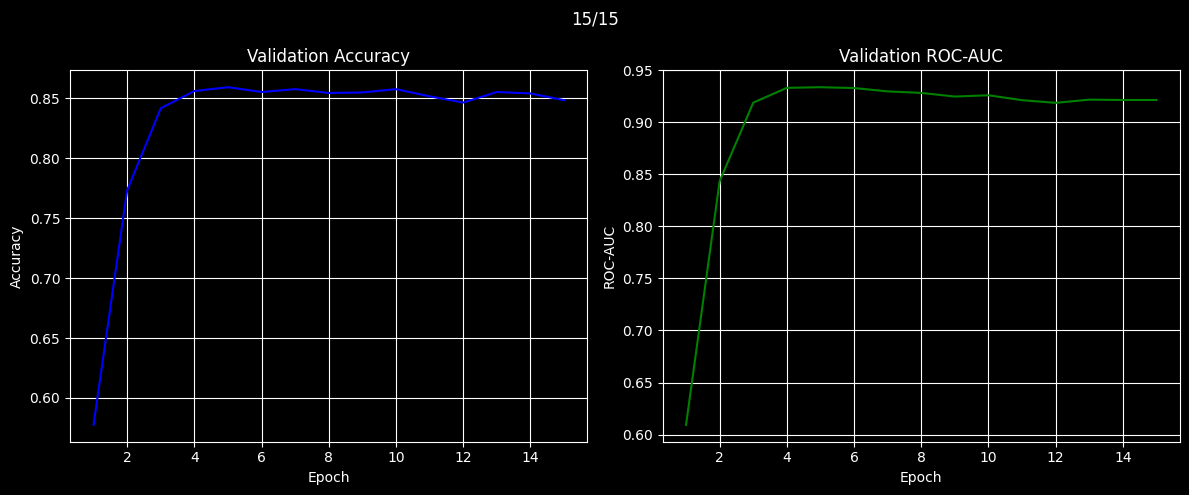

In [133]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128 #256
config = QuantConfig(method="fp32")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=False

model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=15,
    checkpoint_folder="./checkpoint",
    model_name="BaseLSTM",
    device=device
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [134]:
acc, roc_auc = val(
    model,
    test_loader,
    device
)

print(f"Accuracy Base Model: {acc}.")
print(f"ROC-AUC Base Model: {roc_auc}.")
print(f"Время обучения Base Model: {end_time - start_time}.")

Accuracy Base Model: 0.835.
ROC-AUC Base Model: 0.9025761952000001.
Время обучения Base Model: 764.4142856249819.


In [137]:
config = QuantConfig(method="fp32")
quant_factory = FabricQuantizer(config)

model_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_best.to(device)
chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False)
model_best.load_state_dict(chkp["model_state_dict"])

acc, roc_auc = val(
    model_best,
    test_loader,
    device
)

print(f"Accuracy Base Model: {acc}.")
print(f"ROC-AUC Base Model: {roc_auc}.")

Accuracy Base Model: 0.8518.
ROC-AUC Base Model: 0.925873568.


Запомним эти метрики. Будем считать их бейзлайном.

### LSQ Model

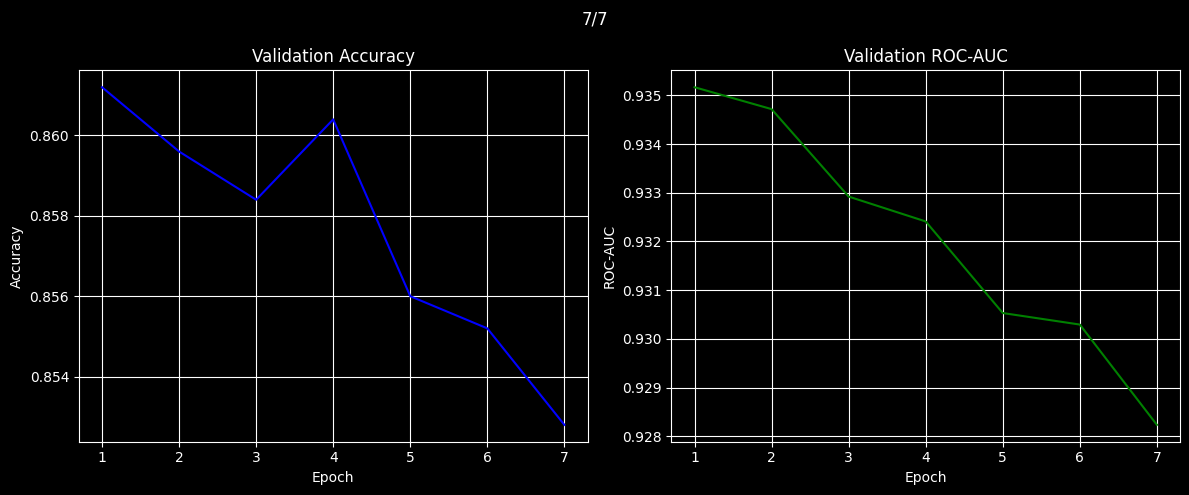

In [192]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = QuantConfig(method="lsq")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

lsq_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
lsq_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
missing, unexpected = lsq_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(lsq_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

# acc, roc_auc = val(lsq_model, val_loader, device)
# print(f"Start: {acc} \n {roc_auc}")

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    lsq_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint/final",
    model_name="LSQ_LSTM",
    device=device
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [116]:
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device).long()
attention_mask = batch["attention_mask"].to(device)

lsq_model.eval()
with torch.no_grad():
    _ = lsq_model(input_ids, attention_mask)

for name, module in lsq_model.named_modules():
    if isinstance(module, LSQQuantizer):
        print(name, "initialized=", module.initialized, "scale=", module.get_scale().item())

lstm.cell.x_quantizer initialized= True scale= 0.11738061159849167
lstm.cell.h_quantizer initialized= True scale= 9.99999993922529e-09
lstm.cell.c_quantizer initialized= True scale= 9.99999993922529e-09
lstm.cell.weights_inp_quantizer initialized= True scale= 0.012849872931838036
lstm.cell.weights_hid_quantizer initialized= True scale= 0.012540072202682495
linear.weight_quantizer initialized= True scale= 0.022805102169513702
linear.input_quantizer initialized= True scale= 0.018425151705741882


In [193]:
model_lsq_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_lsq_best.to(device)
chkp = torch.load("checkpoint/final/LSQ_LSTMbest_roc_auc.pt", weights_only=False)
model_lsq_best.load_state_dict(chkp["model_state_dict"])

acc, roc_auc = val(
    model_lsq_best,
    test_loader,
    device
)


print(f"Accuracy LSQ Model: {acc}.")
print(f"ROC-AUC LSQ Model: {roc_auc}.")
print(f"Время обучения LSQ Model: {end_time - start_time}.")

/var/folders/v6/vtyb69z552dcp1mpzpgv_l9m0000gn/T/ipykernel_31600/1518525218.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x)


Accuracy LSQ Model: 0.8488.
ROC-AUC LSQ Model: 0.923554896.
Время обучения LSQ Model: 798.0886583750253.


Качество вообще не упало, небольшую дельту можно считать погреностью вычислений.

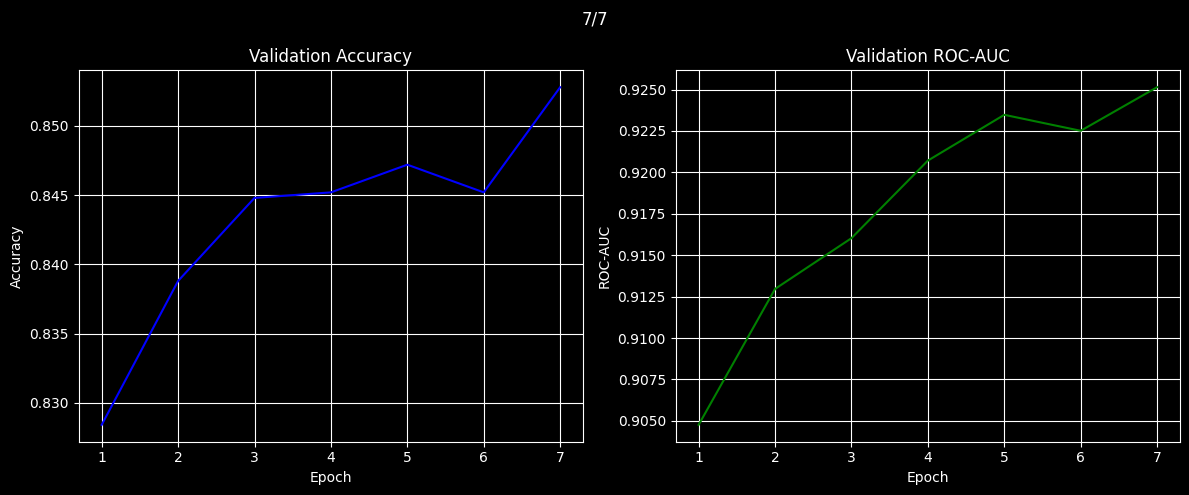

In [202]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = QuantConfig(method="pact")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

pact_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx
)
pact_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
pact_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(pact_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    pact_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint/final",
    model_name="PACT_LSTM",
    device=device
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [203]:
model_pact_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_pact_best.to(device)
chkp = torch.load("checkpoint/final/PACT_LSTMbest_roc_auc.pt", weights_only=False)
model_pact_best.load_state_dict(chkp["model_state_dict"])

acc, roc_auc = val(
    model_pact_best,
    test_loader,
    device
)


print(f"Accuracy LSQ Model: {acc}.")
print(f"ROC-AUC LSQ Model: {roc_auc}.")
print(f"Время обучения LSQ Model: {end_time - start_time}.")

Accuracy LSQ Model: 0.83448.
ROC-AUC LSQ Model: 0.911748144.
Время обучения LSQ Model: 660.9198704999872.


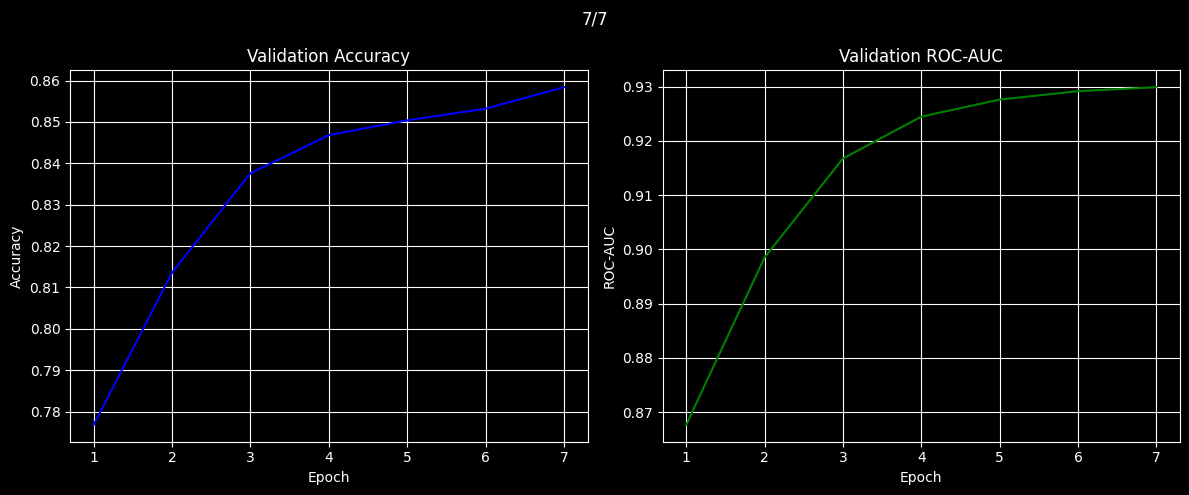

In [204]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = QuantConfig(method="ada")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

ada_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx
)
ada_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
ada_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(ada_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    ada_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint/final",
    model_name="ADA_LSTM",
    device=device,
    use_ada_reg=True
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [205]:
model_ada_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_ada_best.to(device)
chkp = torch.load("checkpoint/final/ADA_LSTMbest_roc_auc.pt", weights_only=False)
model_ada_best.load_state_dict(chkp["model_state_dict"])

acc, roc_auc = val(
    model_ada_best,
    test_loader,
    device
)


print(f"Accuracy ADA Model: {acc}.")
print(f"ROC-AUC ADA Model: {roc_auc}.")
print(f"Время обучения ADA Model: {end_time - start_time}.")

Accuracy ADA Model: 0.84404.
ROC-AUC ADA Model: 0.9178458048.
Время обучения ADA Model: 516.6075852920185.


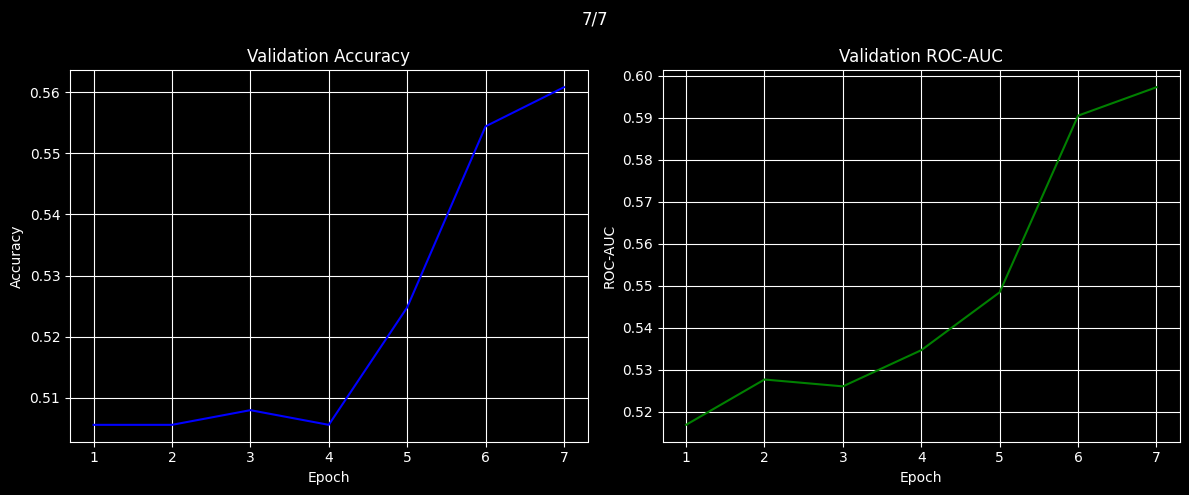

In [212]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = QuantConfig(method="tqt")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

tqt_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx
)
tqt_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
tqt_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(tqt_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    tqt_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint/final",
    model_name="TQT_LSTM",
    device=device,
)

torch.mps.synchronize()
end_time = time.perf_counter()

Надо еще дообучить

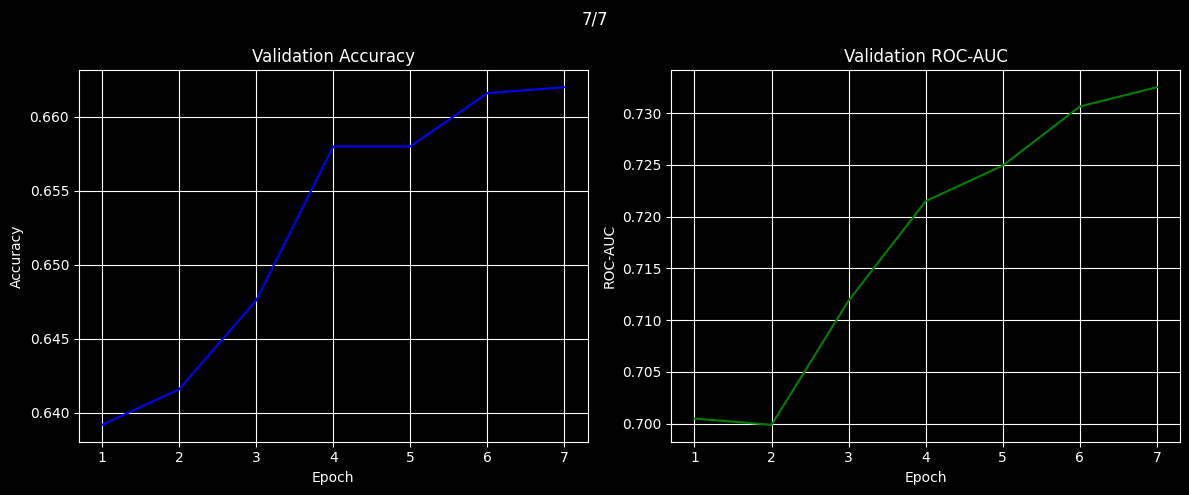

In [10]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = QuantConfig(method="tqt")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

tqt_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx
)
tqt_model.to(device)

tqt_chkp = torch.load("checkpoint/final/TQT_LSTMbest_roc_auc.pt", weights_only=False, map_location=device)
tqt_model.load_state_dict(tqt_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(tqt_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    tqt_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint/final",
    model_name="TQT_LSTM",
    device=device,
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [11]:
model_tqt_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_tqt_best.to(device)
chkp = torch.load("checkpoint/final/TQT_LSTMbest_roc_auc.pt", weights_only=False)
model_tqt_best.load_state_dict(chkp["model_state_dict"])

acc, roc_auc = val(
    model_tqt_best,
    test_loader,
    device
)


print(f"Accuracy ADA Model: {acc}.")
print(f"ROC-AUC ADA Model: {roc_auc}.")
print(f"Время обучения ADA Model: {end_time - start_time}.")

/var/folders/v6/vtyb69z552dcp1mpzpgv_l9m0000gn/T/ipykernel_45538/3943957817.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x)


Accuracy ADA Model: 0.67696.
ROC-AUC ADA Model: 0.7335402208.
Время обучения ADA Model: 1252.1566367089981.


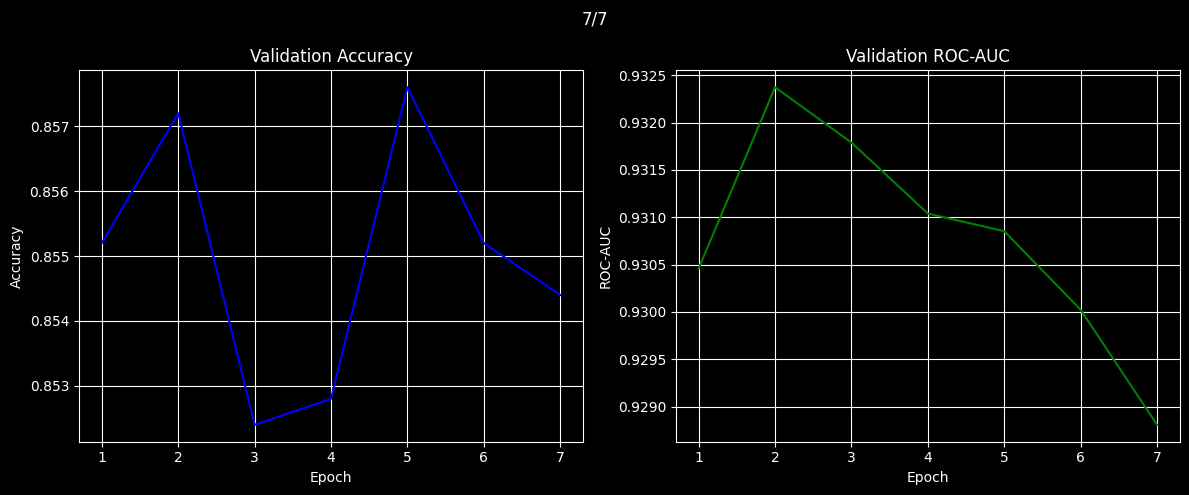

In [206]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = QuantConfig(method="apot")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

apot_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx
)
apot_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
apot_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(apot_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    apot_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint/fina;",
    model_name="ADA_LSTM",
    device=device
)

torch.mps.synchronize()
end_time = time.perf_counter()

Все модели, кроме TQT квантизованной (она обучалась 21 эпоху, 3 раза продолжалось обучение), отлично справляются с квантизацией, качество вообще не упало. Всем кроме ADA было достаточно одной эпохи для дообучения. ADA же дообучалась 6-7 эпох.

### 4 бита квантизации

In [12]:
@dataclass
class Quant4Config:
    method: str = "fp32"
    bits: int = 4

    pact_alpha_init: float = 2.0

    apot_num_powers: int = 4
    apot_max_addends: int = 2
    apot_alphas_init: int = 1.0

    ada_val: bool = False

    tqt_alpha_init: float = 1.0

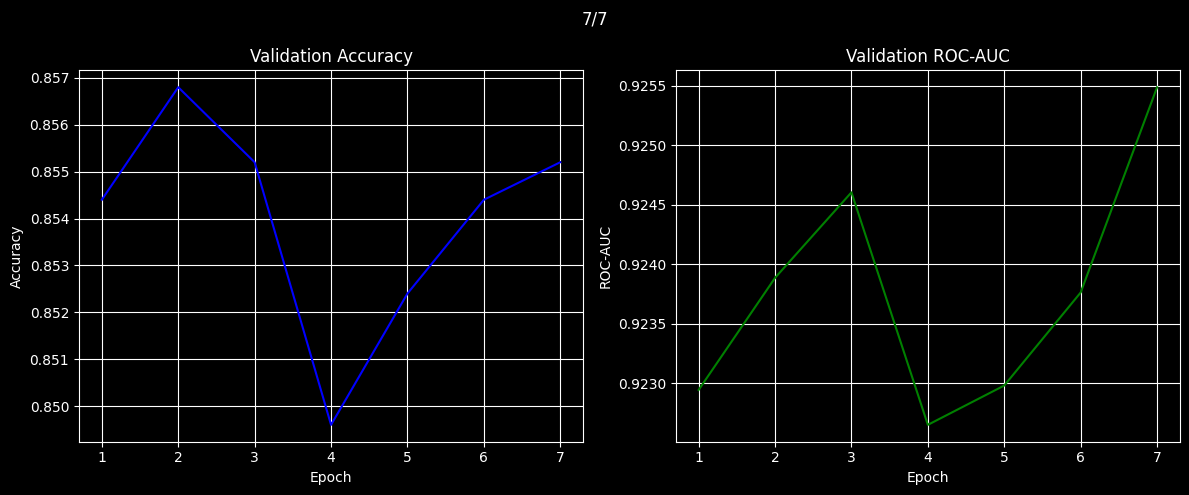

In [183]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = Quant4Config(method="lsq")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

lsq_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
lsq_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
missing, unexpected = lsq_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(lsq_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    lsq_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint",
    model_name="LSQ_INT4_LSTM",
    device=device
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [168]:
model_lsq_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_lsq_best.to(device)
chkp = torch.load("checkpoint/LSQ_LSTMbest_roc_auc.pt", weights_only=False)
model_lsq_best.load_state_dict(chkp["model_state_dict"])

acc, roc_auc = val(
    model_lsq_best,
    test_loader,
    device
)


print(f"Accuracy LSQ INT 4 Model: {acc}.")
print(f"ROC-AUC LSQ INT 4 Model: {roc_auc}.")
print(f"Время обучения LSQ INT 4 Model: {end_time - start_time}.")

/var/folders/v6/vtyb69z552dcp1mpzpgv_l9m0000gn/T/ipykernel_31600/4061422738.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x_tensor = torch.tensor(x)


Accuracy LSQ INT 4 Model: 0.83496.
ROC-AUC LSQ INT 4 Model: 0.9086744127999999.
Время обучения LSQ INT 4 Model: 806.3907314169919.


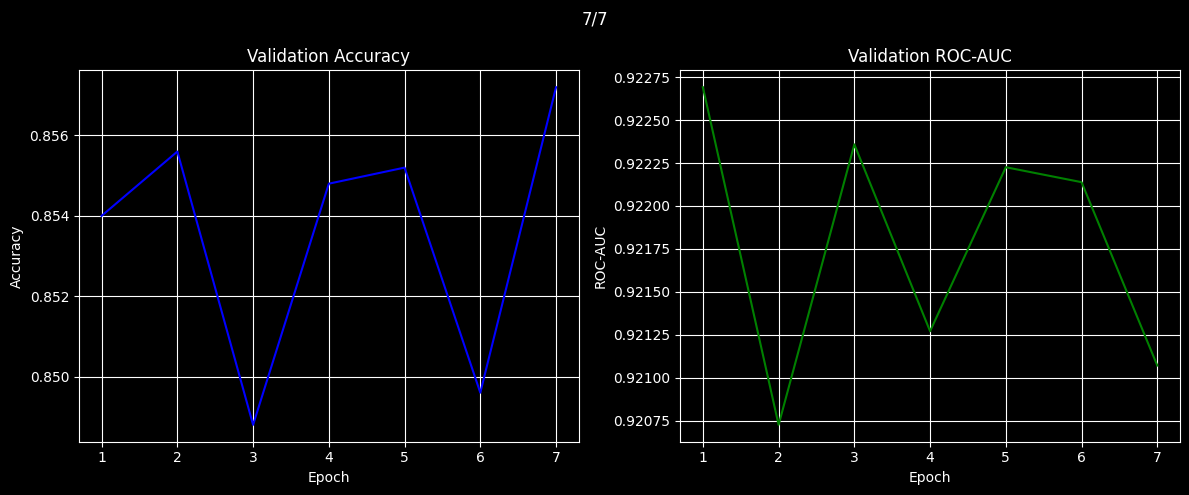

In [177]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = Quant4Config(method="pact")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

pact_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
pact_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
missing, unexpected = pact_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(pact_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

# acc, roc_auc = val(lsq_model, val_loader, device)
# print(f"Start: {acc} \n {roc_auc}")

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    pact_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint",
    model_name="PACT_INT4_LSTM",
    device=device
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [178]:
model_pact_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_pact_best.to(device)
chkp = torch.load("checkpoint/PACT_INT4_LSTMbest_roc_auc.pt", weights_only=False)
model_pact_best.load_state_dict(chkp["model_state_dict"])

acc, roc_auc = val(
    model_pact_best,
    test_loader,
    device
)


print(f"Accuracy PACT INT 4 Model: {acc}.")
print(f"ROC-AUC PACT INT 4 Model: {roc_auc}.")
print(f"Время обучения PACT INT 4 Model: {end_time - start_time}.")

Accuracy PACT INT 4 Model: 0.83536.
ROC-AUC PACT INT 4 Model: 0.9072023776.
Время обучения PACT INT 4 Model: 934.4689842499793.


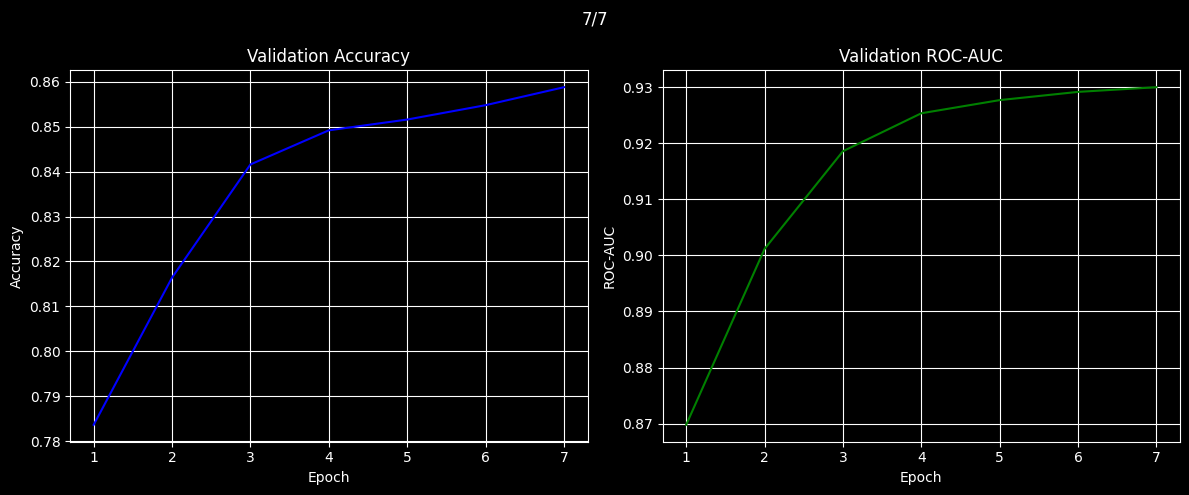

In [179]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = Quant4Config(method="ada")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

ada_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
ada_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
missing, unexpected = ada_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(ada_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    ada_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint",
    model_name="ADA_INT4_LSTM",
    device=device,
    use_ada_reg=True
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [180]:
model_ada_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_ada_best.to(device)
chkp = torch.load("checkpoint/ADA_INT4_LSTMbest_roc_auc.pt", weights_only=False)
model_ada_best.load_state_dict(chkp["model_state_dict"])


for module in model_ada_best.modules():
    if isinstance(module, ADAQuantizer):
        module.val = True

acc, roc_auc = val(
    model_ada_best,
    test_loader,
    device
)


print(f"Accuracy ADA INT 4 Model: {acc}.")
print(f"ROC-AUC ADA INT 4 Model: {roc_auc}.")
print(f"Время обучения ADA INT 4 Model: {end_time - start_time}.")

Accuracy ADA INT 4 Model: 0.8444.
ROC-AUC ADA INT 4 Model: 0.9179055232.
Время обучения ADA INT 4 Model: 542.0057348340051.


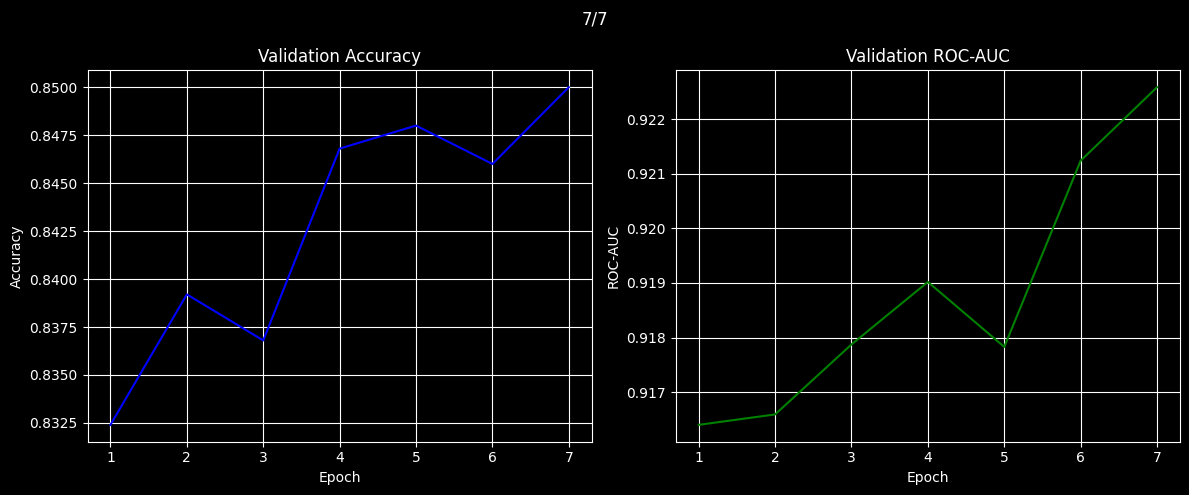

In [181]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = Quant4Config(method="apot")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

apot_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
apot_model.to(device)

fp32_chkp = torch.load("checkpoint/BaseLSTMbest_roc_auc.pt", weights_only=False, map_location=device)
missing, unexpected = apot_model.load_state_dict(fp32_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(apot_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    apot_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=7,
    checkpoint_folder="./checkpoint",
    model_name="APOT_INT4_LSTM",
    device=device
)

torch.mps.synchronize()
end_time = time.perf_counter()

In [182]:
model_apot_best = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx,
    quantized_cell_state=quantized_cell_state
)
model_apot_best.to(device)
chkp = torch.load("checkpoint/APOT_INT4_LSTMbest_roc_auc.pt", weights_only=False)
model_apot_best.load_state_dict(chkp["model_state_dict"])



acc, roc_auc = val(
    model_apot_best,
    test_loader,
    device
)


print(f"Accuracy APOT INT 4 Model: {acc}.")
print(f"ROC-AUC APOT INT 4 Model: {roc_auc}.")
print(f"Время обучения APOT INT 4 Model: {end_time - start_time}.")

Accuracy APOT INT 4 Model: 0.8362.
ROC-AUC APOT INT 4 Model: 0.9125452096.
Время обучения APOT INT 4 Model: 2003.4447078329977.


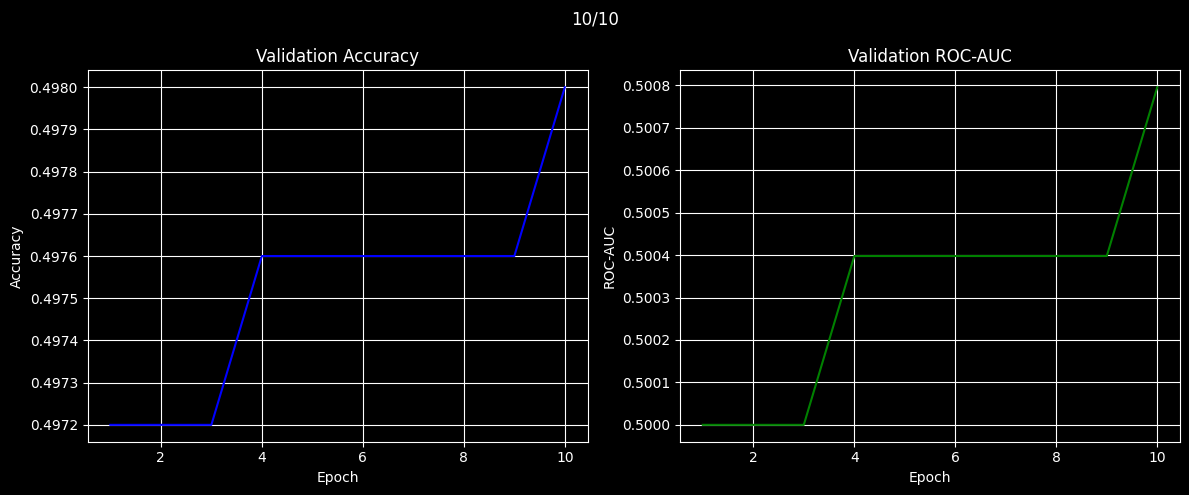

In [13]:
device = torch.device("mps")

emb_size = 128
hidden_size = 128
config = Quant4Config(method="tqt")
quant_factory = FabricQuantizer(config)
pad_idx = tokenizer.pad_token_id
vocab_size=30522
quantized_cell_state=True

tqt_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    quant_factory,
    pad_idx
)
tqt_model.to(device)

fp32_chkp = torch.load("checkpoint/BASELSTMbest_roc_auc.pt", weights_only=False, map_location=device)
tqt_model.load_state_dict(tqt_chkp["model_state_dict"], strict=False)

lr=1e-4
optimizer = torch.optim.AdamW(tqt_model.parameters(), lr=lr, weight_decay=1e-4)
criterion = nn.BCEWithLogitsLoss()

torch.mps.synchronize()
start_time = time.perf_counter()

train_loop(
    tqt_model, 
    optimizer,
    criterion,
    train_loader,
    val_loader,
    epochs=10,
    checkpoint_folder="./checkpoint/final",
    model_name="TQT_INT4_LSTM",
    device=device,
)

torch.mps.synchronize()
end_time = time.perf_counter()

# Тест на CPU

In [35]:
import os
import json
import torch
import numpy as np


def set_lsq_initialized(model):
    cnt = 0

    for module in model.modules():
        if isinstance(module, LSQQuantizer):
            module.initialized = True
            cnt += 1

    print(f"LSQ quantizers marked as initialized: {cnt}")


def get_lsq_scale(quantizer):
    assert isinstance(quantizer, LSQQuantizer), f"Ожидался LSQQuantizer, получен {type(quantizer)}"

    scale = quantizer.get_scale().detach().cpu().float()
    scale = scale.abs().clamp_min(1e-12)

    return scale


@torch.no_grad()
def pack_lsq_int8(weight, quantizer):
    scale = get_lsq_scale(quantizer)

    w = weight.detach().cpu().float()
    w_int = torch.round(w / scale)
    w_int = torch.clamp(w_int, quantizer.qmin, quantizer.qmax)
    w_int = w_int.to(torch.int8)

    return w_int, scale

@torch.no_grad()
def collect_lsq_lstm_int8_weights(model):

    out = {}

    cell = model.lstm.cell

    # 1. Embedding table
    out["emb.weight"] = pack_lsq_int8(
        model.emb.weight,
        cell.x_quantizer
    )

    # 2. LSTM input weights
    out["lstm.cell.weights_inp"] = pack_lsq_int8(
        cell.weights_inp,
        cell.weights_inp_quantizer
    )

    # 3. LSTM hidden weights
    out["lstm.cell.weights_hid"] = pack_lsq_int8(
        cell.weights_hid,
        cell.weights_hid_quantizer
    )

    # 4. Final linear
    out["linear.weights"] = pack_lsq_int8(
        model.linear.weights,
        model.linear.weight_quantizer
    )

    return out


def collect_fp32_lstm_state(model, int8_names):
    fp32 = {}

    for name, tensor in model.state_dict().items():
        if name in int8_names:
            continue

        if "quantizer" in name:
            continue

        fp32[name] = tensor.detach().cpu()

    return fp32


@torch.no_grad()
def export_lsq_lstm_int8_pack(
    lsq_model,
    dst_path,
    src_checkpoint_path=None,
    bits=8,
):
    lsq_model.cpu()
    lsq_model.eval()

    # Важно после load_state_dict
    set_lsq_initialized(lsq_model)

    int8_dict = collect_lsq_lstm_int8_weights(lsq_model)

    print(f"Упаковано int8-тензоров: {len(int8_dict)}")
    for name, (w_int, scale) in int8_dict.items():
        size_mb = w_int.numel() * w_int.element_size() / 1024 / 1024
        print(
            f"{name:30s} "
            f"shape={tuple(w_int.shape)} "
            f"dtype={w_int.dtype} "
            f"scale={scale.item():.6e} "
            f"size={size_mb:.3f} MB"
        )

    fp32_dict = collect_fp32_lstm_state(
        lsq_model,
        set(int8_dict.keys())
    )

    print(f"Оставлено FP32-тензоров: {len(fp32_dict)}")

    obj = {
        "format": "lstm_lsq_int8_v2_with_embedding",

        "int8": {
            name: w_int
            for name, (w_int, _) in int8_dict.items()
        },

        "scales": {
            name: scale
            for name, (_, scale) in int8_dict.items()
        },

        "fp32": fp32_dict,

        "activation_scales": {
            "lstm.cell.x_quantizer": lsq_model.lstm.cell.x_quantizer.get_scale().detach().cpu(),
            "lstm.cell.h_quantizer": lsq_model.lstm.cell.h_quantizer.get_scale().detach().cpu(),
            "lstm.cell.c_quantizer": lsq_model.lstm.cell.c_quantizer.get_scale().detach().cpu(),
            "linear.input_quantizer": lsq_model.linear.input_quantizer.get_scale().detach().cpu(),
        },

        "meta": {
            "src": src_checkpoint_path,
            "emb_size": lsq_model.emb.embedding_dim,
            "hidden_size": lsq_model.lstm.hidden_size,
            "vocab_size": lsq_model.emb.num_embeddings,
            "pad_idx": lsq_model.emb.padding_idx,
            "quantized_cell_state": lsq_model.lstm.cell.quantized_cell_state,
            "bits": bits,
            "method": "lsq",
            "embedding_quantized": True,
            "embedding_scale_source": "lstm.cell.x_quantizer",
            "note": (
                "emb.weight is packed with lstm.cell.x_quantizer scale, "
                "because fake-quant model quantizes embedding output at LSTM input."
            ),
        },
    }

    os.makedirs(os.path.dirname(dst_path) or ".", exist_ok=True)
    torch.save(obj, dst_path)

    print()
    print(f"Сохранено: {dst_path}")

    dst_size = os.path.getsize(dst_path) / 1024 / 1024
    print(f"int8 pack size: {dst_size:.3f} MB")

    if src_checkpoint_path is not None and os.path.exists(src_checkpoint_path):
        src_size = os.path.getsize(src_checkpoint_path) / 1024 / 1024
        print(f"src checkpoint size: {src_size:.3f} MB")
        print(f"compression: x{src_size / dst_size:.2f}")

In [25]:
def build_deployed_lstm_from_meta(meta):
    config = QuantConfig(
        method="fp32",
        bits=meta.get("bits", 8),
    )

    quant_factory = FabricQuantizer(config)

    model = LSTMClassifierQuantized(
        meta["emb_size"],
        meta["hidden_size"],
        quant_factory,
        meta["pad_idx"],
        vocab_size=meta["vocab_size"],
        quantized_cell_state=False,
    )

    return model


@torch.no_grad()
def load_lsq_int8_pack_into_fp32(int8_path, device=torch.device("cpu")):
    obj = torch.load(
        int8_path,
        map_location="cpu",
        weights_only=False,
    )

    if obj.get("format") not in {
        "lstm_lsq_int8_v1",
        "lstm_lsq_int8_v2_with_embedding",
    }:
        raise ValueError(f"Неизвестный формат: {obj.get('format')}")

    meta = obj["meta"]

    model = build_deployed_lstm_from_meta(meta)
    model.cpu()

    # 1. Загружаем FP32-часть
    state_dict_fp32 = obj["fp32"]

    missing, unexpected = model.load_state_dict(
        state_dict_fp32,
        strict=False,
    )

    if missing:
        print(f"[WARN] missing keys: {len(missing)}; first: {missing[:5]}")
    if unexpected:
        print(f"[WARN] unexpected keys: {len(unexpected)}; first: {unexpected[:5]}")

    # 2. Dequant int8-весов обратно в FP32 и кладём в модель
    sd = model.state_dict()

    for name, w_int in obj["int8"].items():
        scale = obj["scales"][name]

        w_fp = w_int.to(torch.float32) * scale.to(torch.float32)

        if name in sd:
            sd[name].copy_(w_fp.to(sd[name].dtype))
            print(f"Loaded int8 -> fp32: {name}")
        else:
            print(f"[WARN] Не нашёл {name} в model.state_dict()")

    model.to(device)
    model.eval()

    return model, meta, obj

In [32]:
cpu_device = torch.device("cpu")
LSQ_CKPT = "checkpoint/final/LSQ_LSTMbest_roc_auc.pt"
INT8_PACK_PATH = "checkpoint/final/LSQ_LSTM_INT8_PACK_WITH_EMB.pt"

emb_size = 128
hidden_size = 128
pad_idx = tokenizer.pad_token_id
vocab_size = 30522

lsq_config = QuantConfig(method="lsq", bits=8)
lsq_quant_factory = FabricQuantizer(lsq_config)

lsq_model = LSTMClassifierQuantized(
    emb_size,
    hidden_size,
    lsq_quant_factory,
    pad_idx,
    vocab_size=vocab_size,
    quantized_cell_state=True,
)

checkpoint = torch.load(
    LSQ_CKPT,
    map_location="cpu",
    weights_only=False,
)

lsq_model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=False,
)

set_lsq_initialized(lsq_model)

lsq_model.cpu()
lsq_model.eval()

export_lsq_lstm_int8_pack(
    lsq_model,
    dst_path=INT8_PACK_PATH,
    src_checkpoint_path=LSQ_CKPT,
    bits=8,
)

LSQ quantizers marked as initialized: 7
LSQ quantizers marked as initialized: 7
Упаковано int8-тензоров: 4
emb.weight                     shape=(30522, 128) dtype=torch.int8 scale=1.327838e-01 size=3.726 MB
lstm.cell.weights_inp          shape=(512, 128) dtype=torch.int8 scale=9.777521e-03 size=0.062 MB
lstm.cell.weights_hid          shape=(512, 128) dtype=torch.int8 scale=9.417114e-03 size=0.062 MB
linear.weights                 shape=(1, 128) dtype=torch.int8 scale=1.987966e-02 size=0.000 MB
Оставлено FP32-тензоров: 3

Сохранено: checkpoint/final/LSQ_LSTM_INT8_PACK_WITH_EMB.pt
int8 pack size: 3.861 MB
src checkpoint size: 15.413 MB
compression: x3.99


Сжатие в 4 раза

In [29]:
def disk_size_mb(path):
    if path is None or not os.path.exists(path):
        return None

    return os.path.getsize(path) / 1024 / 1024


def fmt(v, fmtstr="{:.4f}"):
    return fmtstr.format(v) if v is not None else "-"


def benchmark_three_versions(
    fp32_model,
    lsq_fake_model,
    int8_deployed_model,
    batches,
    fp32_path=None,
    lsq_path=None,
    int8_path=None,
    warmup=10,
    repeats=100,
):
    rows = []

    def run_one(label, model, path):
        model.cpu()
        model.eval()

        acc, roc_auc = evaluate_on_batches(model, batches)

        speed = benchmark_cpu_model(
            model,
            batches,
            warmup=warmup,
            repeats=repeats,
        )

        size = disk_size_mb(path)

        row = {
            "label": label,
            "disk_mb": size,
            "acc": acc,
            "roc_auc": roc_auc,
            "median_ms": speed["median_ms_per_batch"],
            "mean_ms": speed["mean_ms_per_batch"],
            "samples_per_second": speed["samples_per_second"],
        }

        rows.append(row)

        print(
            f"{label:22s} "
            f"acc={acc:.4f} "
            f"roc_auc={roc_auc if not np.isnan(roc_auc) else float('nan'):.4f} "
            f"median_ms={speed['median_ms_per_batch']:.2f} "
            f"disk={fmt(size, '{:.3f}')} MB"
        )

    print("=== FP32 baseline ===")
    run_one("FP32 baseline", fp32_model, fp32_path)

    print()
    print("=== QAT fake-quant LSQ ===")
    run_one("QAT fake-quant", lsq_fake_model, lsq_path)

    print()
    print("=== INT8 deployed pack ===")
    run_one("INT8 deployed", int8_deployed_model, int8_path)

    print()
    print("========== СВОДКА ==========")

    header = (
        f'{"label":22s} {"disk MB":>10s} {"x compr":>8s} '
        f'{"median ms":>10s} {"samples/s":>12s} {"acc":>8s} {"roc_auc":>8s}'
    )

    print(header)
    print("-" * len(header))

    base_size = next(
        (r["disk_mb"] for r in rows if r["label"] == "FP32 baseline"),
        None,
    )

    for r in rows:
        if base_size is not None and r["disk_mb"] is not None:
            ratio = base_size / r["disk_mb"]
        else:
            ratio = 1.0

        print(
            f'{r["label"]:22s} '
            f'{fmt(r["disk_mb"], "{:>10.3f}"):>10s} '
            f'{ratio:>8.2f} '
            f'{r["median_ms"]:>10.2f} '
            f'{r["samples_per_second"]:>12.2f} '
            f'{r["acc"]:>8.4f} '
            f'{r["roc_auc"]:>8.4f}'
        )

    return rows

In [31]:
deployed_int8_model, int8_meta, int8_obj = load_lsq_int8_pack_into_fp32(
    INT8_PACK_PATH,
    device=torch.device("cpu"),
)

benchmark_batches = prepare_cpu_batches(
    test_loader,
    max_batches=None,
)

rows = benchmark_three_versions(
    fp32_model=fp32_model,
    lsq_fake_model=lsq_model,
    int8_deployed_model=deployed_int8_model,
    batches=benchmark_batches,
    fp32_path="checkpoint/BaseLSTMbest_roc_auc.pt",
    lsq_path=LSQ_CKPT,
    int8_path=INT8_PACK_PATH,
    warmup=10,
    repeats=100,
)

[WARN] missing keys: 4; first: ['emb.weight', 'lstm.cell.weights_inp', 'lstm.cell.weights_hid', 'linear.weights']
Loaded int8 -> fp32: emb.weight
Loaded int8 -> fp32: lstm.cell.weights_inp
Loaded int8 -> fp32: lstm.cell.weights_hid
Loaded int8 -> fp32: linear.weights
=== FP32 baseline ===
FP32 baseline          acc=0.8518 roc_auc=0.9259 median_ms=27.74 disk=15.411 MB

=== QAT fake-quant LSQ ===
QAT fake-quant         acc=0.8490 roc_auc=0.9237 median_ms=59.85 disk=15.413 MB

=== INT8 deployed pack ===
INT8 deployed          acc=0.8509 roc_auc=0.9245 median_ms=27.41 disk=3.861 MB

========== СВОДКА ==========
label                     disk MB  x compr  median ms    samples/s      acc  roc_auc
------------------------------------------------------------------------------------
FP32 baseline              15.411     1.00      27.74      2306.54   0.8518   0.9259
QAT fake-quant             15.413     1.00      59.85      1068.09   0.8490   0.9237
INT8 deployed               3.861     3.99   